In [6]:
# ===== Cell 1: imports & helpers =====
from pathlib import Path
import importlib.util, json, time, math, csv, re
from typing import Tuple, Dict, Any, List, Optional
import numpy as np
import nibabel as nib

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import binary_erosion, distance_transform_edt

# ---------- Metrics ----------
def dice_soft(y: np.ndarray, p: np.ndarray) -> float:
    y = y.astype(np.float64); p = p.astype(np.float64)
    inter = (y * p).sum()
    return float((2.0 * inter) / (y.sum() + p.sum() + 1e-12))

def dice_hard(ybin: np.ndarray, pbin: np.ndarray) -> float:
    ybin = ybin.astype(np.float64); pbin = pbin.astype(np.float64)
    inter = (ybin * pbin).sum()
    return float((2.0 * inter) / (ybin.sum() + pbin.sum() + 1e-12))

def precision_recall(ybin: np.ndarray, pbin: np.ndarray):
    tp = float((ybin & pbin).sum())
    fp = float((~ybin & pbin).sum())
    fn = float((ybin & ~pbin).sum())
    prec = tp / (tp + fp + 1e-12)
    rec  = tp / (tp + fn + 1e-12)
    return float(prec), float(rec)

# ---------- Surface distances ----------
def _surface(mask: np.ndarray) -> np.ndarray:
    s = np.ones((3,3,3), dtype=bool)
    er = binary_erosion(mask.astype(bool), structure=s, border_value=0)
    return mask.astype(bool) & (~er)

def _directed_surface_distances(A_surf: np.ndarray, B_surf: np.ndarray, spacing):
    if not A_surf.any():
        return np.empty((0,), dtype=np.float64)
    edt = distance_transform_edt(~B_surf, sampling=spacing)
    return edt[A_surf]

def hd_assd(ybin: np.ndarray, pbin: np.ndarray, spacing=(1.0,1.0,1.0)) -> Dict[str, float]:
    ysurf = _surface(ybin); psurf = _surface(pbin)
    if (not ysurf.any()) or (not psurf.any()):
        return {"hd": float("nan"), "hd95": float("nan"), "assd": float("nan")}
    dY = _directed_surface_distances(ysurf, psurf, spacing)
    dP = _directed_surface_distances(psurf, ysurf, spacing)
    both = np.concatenate([dY, dP]) if (dY.size and dP.size) else np.array([], float)
    hd   = float(np.max(both)) if both.size else float("nan")
    hd95 = float(np.percentile(both, 95)) if both.size else float("nan")
    assd = float((dY.mean() + dP.mean()) / 2.0) if (dY.size and dP.size) else float("nan")
    return {"hd": hd, "hd95": hd95, "assd": assd}

# ---------- Key normalization ----------
def _norm_key(name: str) -> str:
    n = re.sub(r"\.nii(\.gz)?$", "", name or "")
    n = re.sub(r"_T1w", "", n)
    n = re.sub(r"_MNI_norm", "", n)
    n = re.sub(r"_lesion_mask(_MNI)?_clean", "", n)
    n = re.sub(r"_(soft|hard)$", "", n)
    return n

# ---------- Plotting utilities ----------
def _dropna(a):
    a = np.asarray(a, float)
    return a[~np.isnan(a)]

def _robust_limits_log(arr):
    arr = _dropna(arr)
    if arr.size == 0:
        return (1e-2, 1.0)
    lo = np.percentile(arr, 5)
    hi = np.percentile(arr, 95)
    lo = max(lo, 1e-2)
    hi = max(hi, lo * 1.5)
    return (lo, hi)

def violin(ax, data_seq, labels, y_label=None, ylim=None, log=False, title=None):
    # Always use numeric x positions to avoid categorical converter issues.
    clean = [_dropna(x) for x in data_seq]
    nonempty = [x if x.size else np.array([np.nan]) for x in clean]
    pos = np.arange(1, len(nonempty) + 1, dtype=float)
    parts = ax.violinplot(nonempty, positions=pos, showmeans=True, showmedians=True, widths=0.8)
    for b in parts.get('bodies', []):
        b.set_alpha(0.6)
    if parts.get('cmeans') is not None: parts['cmeans'].set_linewidth(1.5)
    if parts.get('cmedians') is not None: parts['cmedians'].set_linewidth(1.5)
    ax.set_xticks(pos)
    ax.set_xticklabels(labels, rotation=0)
    if y_label: ax.set_ylabel(y_label)
    if log: ax.set_yscale("log")
    if ylim: ax.set_ylim(*ylim)
    elif not log: ax.set_ylim(0, 1.0)
    if title: ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.2)

def composite_figure(per_case_rows: List[Dict[str, Any]], summary: Dict[str, Any], title="Held-out evaluation"):
    # pull arrays
    soft = np.array([r["soft_dice"] for r in per_case_rows], float)
    hard_key = next((k for k in per_case_rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    hard = np.array([r[hard_key] for r in per_case_rows], float)
    prec = np.array([r["precision"] for r in per_case_rows], float)
    rec  = np.array([r["recall"] for r in per_case_rows], float)
    hd   = np.array([r["hd"] for r in per_case_rows], float)
    hd95 = np.array([r["hd95"] for r in per_case_rows], float)
    assd = np.array([r["assd"] for r in per_case_rows], float)

    fig = plt.figure(figsize=(10,8))
    gs = GridSpec(2, 1, height_ratios=[3,2], hspace=0.35)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    # Top: Dice/PR violins
    violin(ax_top, [soft, hard, prec, rec],
           ["Soft Dice", "Hard Dice", "Precision", "Recall"],
           y_label="Value", title="Per-case distributions (Dice / Precision / Recall)")

    # Inset summary bars (numeric x positions)
    inset = ax_top.inset_axes([0.62, 0.55, 0.35, 0.38])
    bar_labels = ["Macro soft", "Macro hard", "Micro soft", "Micro hard"]
    bar_vals   = [summary["macro_soft"], summary["macro_hard"], summary["micro_soft"], summary["micro_hard"]]
    x = np.arange(len(bar_labels), dtype=float)
    inset.bar(x, bar_vals)
    inset.set_ylim(0, 1.0)
    inset.set_xticks(x)
    inset.set_xticklabels(bar_labels, rotation=20, ha='right', fontsize=8)
    inset.set_title("Summary Dice", fontsize=9)
    inset.grid(True, axis='y', alpha=0.2)

    # Bottom: distance violins (log scale, robust ylim)
    all_dist = np.concatenate([_dropna(hd), _dropna(hd95), _dropna(assd)]) if (
        np.isfinite(hd).any() or np.isfinite(hd95).any() or np.isfinite(assd).any()
    ) else np.array([1.0])
    ylim = _robust_limits_log(all_dist)
    violin(ax_bot, [hd, hd95, assd],
           ["HD", "HD95", "ASSD"],
           y_label="Distance (log scale; see units in summary)",
           ylim=ylim, log=True, title="Surface distance metrics (per-case)")

    fig.suptitle(title, y=0.99, fontsize=14)
    plt.tight_layout()
    return fig


In [7]:
# ===== Cell 2: end-to-end evaluation & save =====
def run_eval_and_viz(
    RUN_DIR: Path,
    TEST_DIR: Path,
    TRAIN_MOD_PATH: Path,
    T1_DIR: Optional[Path] = None,
    MSK_DIR: Optional[Path] = None,
    MANIFEST_CSV: Optional[Path] = None,
    TH: float = 0.50,
    save_prefix: str = "test",
    dataset_tag: str = "hires"
):
    # ---- import training module ----
    spec = importlib.util.spec_from_file_location("arc_seg_train", TRAIN_MOD_PATH)
    seg = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(seg)

    T1_DIR = T1_DIR or (TEST_DIR / "t1")
    MSK_DIR = MSK_DIR or (TEST_DIR / "masks")

    # ---- load model ----
    models_dir     = RUN_DIR / "models"
    callbacks_dir  = RUN_DIR / "callbacks"
    full_models    = sorted(models_dir.glob("*.keras"))
    best_weights   = callbacks_dir / "best_model_dynamic.weights.h5"
    cfg_json_path  = models_dir / "config.json"
    custom_objects = {
        "ResidualConvBlock": seg.ResidualConvBlock,
        "VisionMambaBlock": seg.VisionMambaBlock,
        "SAM2Attention": seg.SAM2Attention,
        "CombinedLoss": seg.CombinedLoss,
        "dice_coefficient": seg.dice_coefficient,
        "dice_loss": seg.dice_loss,
        "boundary_loss": seg.boundary_loss,
    }
    try:
        from keras.saving import load_model as keras_load_model
    except Exception:
        from tensorflow.keras.models import load_model as keras_load_model

    if full_models:
        model_path = full_models[-1]
        print(f"Loading FULL model: {model_path}")
        model = keras_load_model(model_path, compile=False, custom_objects=custom_objects)
        INPUT_SHAPE = tuple(model.input_shape[1:])
    else:
        assert cfg_json_path.exists(), f"Missing {cfg_json_path}"
        with open(cfg_json_path) as f:
            saved_cfg = json.load(f)
        cfg = seg.DynamicTrainingConfig(
            DATA_DIR=TEST_DIR, MODEL_DIR=models_dir, CALLBACKS_DIR=callbacks_dir,
            INPUT_SHAPE=tuple(saved_cfg["INPUT_SHAPE"]) if saved_cfg.get("INPUT_SHAPE") else None,
            BASE_FILTERS=int(saved_cfg.get("BASE_FILTERS", 8)),
            SAM_HEADS=int(saved_cfg.get("SAM_HEADS", 2)),
        )
        if not cfg.INPUT_SHAPE:
            raise RuntimeError("INPUT_SHAPE missing in saved config; cannot rebuild model.")
        INPUT_SHAPE = cfg.INPUT_SHAPE
        print("Rebuilding model from config.json and loading best weights…")
        model = seg.build_dynamic_model(cfg)
        model.load_weights(str(best_weights))

    print("INPUT_SHAPE:", INPUT_SHAPE)

    # ---- dataset ----
    if T1_DIR.exists() and MSK_DIR.exists():
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR, IMAGES_DIR=T1_DIR, MASKS_DIR=MSK_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    else:
        cfg_eval = seg.DynamicTrainingConfig(DATA_DIR=TEST_DIR,
                                             MODEL_DIR=RUN_DIR/"_tmp_models", CALLBACKS_DIR=RUN_DIR/"_tmp_callbacks")
    cfg_eval.INPUT_SHAPE = INPUT_SHAPE
    pairs, lesion_presence = seg.load_generic_dataset(cfg_eval)
    print(f"Pairs: {len(pairs)} | % non-empty masks: {lesion_presence.mean()*100:.1f}%")

    # ---- spacing inference (best-effort) ----
    use_mm = True
    spacing = (1.0, 1.0, 1.0)
    try:
        z = nib.load(str(pairs[0][0])).header.get_zooms()[:3]
        if any(abs(zi - 1.0) > 0.05 for zi in z):
            use_mm = False
    except Exception:
        use_mm = False

    # ---- quality metrics computed on each degraded image (not borrowed from base manifest) ----
    from scipy.ndimage import laplace

    def _q_zscore_in_brain(vol: np.ndarray):
        m = vol != 0
        out = np.zeros_like(vol, dtype=np.float32)
        if m.any():
            vv = vol[m].astype(np.float32)
            sd = float(vv.std())
            sd = sd if sd > 0 else 1.0
            out[m] = (vv - float(vv.mean())) / sd
        return out, m

    def _q_fwhm_gaussian_acf(img: np.ndarray, mask: np.ndarray, shifts=(1, 2, 3), max_fwhm_mm=50.0, min_pairs=1000):
        cors = []
        for sh in shifts:
            for axis in (0, 1, 2):
                sf = [slice(None)] * 3
                sg = [slice(None)] * 3
                sf[axis] = slice(0, -sh)
                sg[axis] = slice(sh, None)
                f = img[tuple(sf)]
                g = img[tuple(sg)]
                m = mask[tuple(sf)] & mask[tuple(sg)]
                if int(m.sum()) < min_pairs:
                    continue
                fv = f[m] - float(f[m].mean())
                gv = g[m] - float(g[m].mean())
                sd = float(fv.std()) * float(gv.std())
                if sd <= 1e-8:
                    continue
                r = float((fv * gv).mean() / sd)
                r = max(min(r, 0.999), 1e-6)
                cors.append((sh, r))
        if not cors:
            return float("nan")

        by_shift = {}
        for sh, rr in cors:
            by_shift.setdefault(sh, []).append(rr)
        s2 = np.array(sorted(by_shift), dtype=float) ** 2
        R = np.array([np.mean(by_shift[sh]) for sh in sorted(by_shift)], dtype=float)
        lnR = np.log(R)
        if not np.all(np.isfinite(lnR)):
            return float("nan")

        A = np.vstack([np.ones_like(s2), s2]).T
        _, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
        if (not np.isfinite(b)) or b >= -1e-6:
            return float("nan")

        sigma = np.sqrt(-1.0 / (2.0 * b))
        fwhm = 2.355 * sigma
        if (not np.isfinite(fwhm)) or fwhm <= 0 or fwhm > max_fwhm_mm:
            return float("nan")
        return float(fwhm)

    def _q_high_freq_energy_ratio(img: np.ndarray, mask: np.ndarray, cutoff=0.25):
        from numpy.fft import fftn, fftshift

        vol = np.zeros_like(img, dtype=np.float32)
        vol[mask] = img[mask]
        F = fftshift(fftn(vol))
        P = (np.abs(F) ** 2).astype(np.float64)
        tot = float(P.sum())
        if (not np.isfinite(tot)) or tot <= 1e-12:
            return float("nan")

        nx, ny, nz = img.shape
        cx, cy, cz = (np.array(img.shape) - 1) / 2.0
        x = np.arange(nx) - cx
        y = np.arange(ny) - cy
        z = np.arange(nz) - cz
        X, Y, Z = np.meshgrid(x, y, z, indexing="ij")
        rx = np.abs(X) / (nx / 2.0)
        ry = np.abs(Y) / (ny / 2.0)
        rz = np.abs(Z) / (nz / 2.0)
        r = np.sqrt((rx ** 2 + ry ** 2 + rz ** 2) / 3.0)

        hf = float(P[r >= cutoff].sum())
        return float(hf / (tot + 1e-12))

    def _q_laplacian_variance(img: np.ndarray, mask: np.ndarray):
        L = laplace(img)
        vals = L[mask]
        return float(vals.var()) if vals.size else float("nan")

    quality_by_key: Dict[str, Dict[str, float]] = {}

    # ---- eval loop ----
    macro_softs, macro_hards = [], []
    precisions, recalls = [], []
    hds, hd95s, assds = [], [], []   # <-- fixed tuple init
    s_inter_soft = np.float64(0.0); s_sumy_soft = np.float64(0.0); s_sump_soft = np.float64(0.0)

    per_case_rows = []
    for i, (img_p, msk_p) in enumerate(pairs, 1):
        img = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        y   = seg._load_and_preprocess_mask(str(msk_p),  INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32); x[0,...,0] = img
        p  = model.predict(x, verbose=0)[0,...,0].astype(np.float32)
        pb = (p >= TH)

        ds = dice_soft(y, p)
        dh = dice_hard(y > 0.5, pb)
        yy = (y > 0.5)
        prec, rec = precision_recall(yy, pb)
        dists = hd_assd(yy, pb, spacing=spacing)

        macro_softs.append(ds); macro_hards.append(dh)
        precisions.append(prec); recalls.append(rec)
        hds.append(dists["hd"]); hd95s.append(dists["hd95"]); assds.append(dists["assd"])

        s_inter_soft += (y.astype(np.float64) * p.astype(np.float64)).sum()
        s_sumy_soft  += y.sum(dtype=np.float64)
        s_sump_soft  += p.sum(dtype=np.float64)

        # quality metrics on the current degraded image
        q_key = _norm_key(Path(img_p).stem)
        try:
            raw = nib.load(str(img_p)).get_fdata().astype(np.float32)
            zimg, qmask = _q_zscore_in_brain(raw)
            if int(qmask.sum()) >= 5000:
                q_fwhm = _q_fwhm_gaussian_acf(zimg, qmask)
                q_hfe = _q_high_freq_energy_ratio(zimg, qmask, cutoff=0.25)
                q_lvar = _q_laplacian_variance(zimg, qmask)
            else:
                q_fwhm = q_hfe = q_lvar = float("nan")
        except Exception:
            q_fwhm = q_hfe = q_lvar = float("nan")

        quality_by_key[q_key] = {
            "fwhm_mm": float(q_fwhm),
            "hi_freq_energy": float(q_hfe),
            "lap_var": float(q_lvar),
        }

        if i % 10 == 0 or i == len(pairs):
            print(f"[{i}/{len(pairs)}] soft={ds:.4f} hard@{TH:.2f}={dh:.4f} | P={prec:.3f} R={rec:.3f} | "
                  f"HD={dists['hd']:.2f} HD95={dists['hd95']:.2f} ASSD={dists['assd']:.2f}")

        per_case_rows.append({
            "dataset_tag": dataset_tag,
            "key": _norm_key(Path(img_p).stem),
            "soft_dice": float(ds),
            f"hard_dice_at_{TH:.2f}": float(dh),
            "precision": float(prec),
            "recall": float(rec),
            "hd": float(dists["hd"]),
            "hd95": float(dists["hd95"]),
            "assd": float(dists["assd"]),
            "img_path": str(img_p),
            "mask_path": str(msk_p),
        })

    # micro hard (exact)
    s_inter_hard = np.float64(0.0); s_sumy_hard  = np.float64(0.0); s_sump_hard  = np.float64(0.0)
    for img_p, msk_p in pairs:
        y = seg._load_and_preprocess_mask(str(msk_p), INPUT_SHAPE[:-1]).astype(np.float32)
        x = np.zeros((1,*INPUT_SHAPE), np.float32)
        x[0,...,0] = seg._load_and_preprocess_image(str(img_p), INPUT_SHAPE[:-1]).astype(np.float32)
        p = model.predict(x, verbose=0)[0,...,0]
        pb = (p >= TH).astype(np.float64)
        s_inter_hard += (y.astype(np.float64) * pb).sum()
        s_sumy_hard  += y.sum(dtype=np.float64)
        s_sump_hard  += pb.sum(dtype=np.float64)

    macro_soft = float(np.mean(macro_softs))
    macro_hard = float(np.mean(macro_hards))
    micro_soft = float((2.0*s_inter_soft) / (s_sumy_soft + s_sump_soft + 1e-12))
    micro_hard = float((2.0*s_inter_hard) / (s_sumy_hard + s_sump_hard + 1e-12))

    out_dir = RUN_DIR / "test_eval"; out_dir.mkdir(parents=True, exist_ok=True)
    ts = time.strftime("%Y%m%d_%H%M%S")
    csv_path  = out_dir / f"{save_prefix}_metrics_{ts}.csv"
    json_path = out_dir / f"{save_prefix}_metrics_summary_{ts}.json"
    png_path  = out_dir / f"{save_prefix}_composite_{ts}.png"

    # write CSV
    with open(csv_path, "w", newline="") as f:
        cols = list(per_case_rows[0].keys()) if per_case_rows else []
        wr = csv.DictWriter(f, fieldnames=cols)
        wr.writeheader(); wr.writerows(per_case_rows)

    summary = {
        "threshold": TH,
        "macro_soft": macro_soft, "macro_hard": macro_hard,
        "micro_soft": micro_soft, "micro_hard": micro_hard,
        "n_cases": len(pairs),
        "distance_units": "mm (assumed 1mm isotropic MNI)" if use_mm else "voxel units (spacing unknown on model grid)",
        "run_dir": str(RUN_DIR), "test_dir": str(TEST_DIR),
        "csv_path": str(csv_path)
    }
    with open(json_path, "w") as f:
        json.dump(summary, f, indent=2)

    print("\n=== SUMMARY ===")
    print(f"Macro soft Dice : {macro_soft:.4f}")
    print(f"Macro hard Dice : {macro_hard:.4f}")
    print(f"Micro soft Dice : {micro_soft:.4f}")
    print(f"Micro hard Dice : {micro_hard:.4f}")
    print(f"Per-case CSV    : {csv_path}")
    print(f"Summary  JSON   : {json_path}")

    # figure
    fig = composite_figure(per_case_rows, summary,
                           title=f"{dataset_tag}: held-out evaluation")
    fig.savefig(png_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Composite figure:", png_path)

    # Merge with manifest metadata, but ALWAYS use per-image computed quality metrics.
    merged_csv_path = None
    manifest = {}
    if MANIFEST_CSV and Path(MANIFEST_CSV).exists():
        with open(MANIFEST_CSV, newline="") as f:
            for row in csv.DictReader(f):
                k = (row.get("key") or "").strip()
                if not k:
                    for src in (row.get("t1_path"), row.get("mask_path")):
                        if src:
                            k = _norm_key(Path(src).name)
                            break
                if not k:
                    continue
                manifest[k] = row

    merged = []
    for r in per_case_rows:
        m = manifest.get(r["key"], {})
        q = quality_by_key.get(r["key"], {})
        row = {**r, **{f"mf_{kk}": vv for kk, vv in m.items()}}

        # Backfill baseline metadata if no manifest row is found.
        row.setdefault("mf_dataset", dataset_tag)
        row.setdefault("mf_key", r["key"])
        row.setdefault("mf_t1_path", r.get("img_path", ""))
        row.setdefault("mf_mask_path", r.get("mask_path", ""))
        row.setdefault("mf_bin", dataset_tag)

        # Critical fix: quality comes from degraded image, not source manifest.
        row["mf_fwhm_mm"] = float(q.get("fwhm_mm", np.nan))
        row["mf_hi_freq_energy"] = float(q.get("hi_freq_energy", np.nan))
        row["mf_lap_var"] = float(q.get("lap_var", np.nan))
        merged.append(row)

    # Recompute mf_score from the per-image quality values (dataset-level z-score sum).
    fwhm_arr = np.array([float(r.get("mf_fwhm_mm", np.nan)) for r in merged], dtype=float)
    hfe_arr  = np.array([float(r.get("mf_hi_freq_energy", np.nan)) for r in merged], dtype=float)
    lap_arr  = np.array([float(r.get("mf_lap_var", np.nan)) for r in merged], dtype=float)

    def _z(v: np.ndarray) -> np.ndarray:
        out = np.full(v.shape, np.nan, dtype=float)
        m = np.isfinite(v)
        if m.sum() == 0:
            return out
        mu = float(np.mean(v[m]))
        sd = float(np.std(v[m]))
        if sd < 1e-12:
            out[m] = 0.0
        else:
            out[m] = (v[m] - mu) / sd
        return out

    score = _z(hfe_arr) + _z(lap_arr) + _z(-fwhm_arr)
    for rr, sc in zip(merged, score):
        rr["mf_score"] = float(sc) if np.isfinite(sc) else np.nan

    if merged:
        merged_csv_path = out_dir / f"{save_prefix}_metrics_with_manifest_{ts}.csv"
        with open(merged_csv_path, "w", newline="") as f:
            wr = csv.DictWriter(f, fieldnames=list(merged[0].keys()))
            wr.writeheader()
            wr.writerows(merged)
        print("Merged CSV with manifest ->", merged_csv_path)

    return per_case_rows, summary, {"per_case_csv": csv_path, "summary_json": json_path,
                                    "figure_png": png_path, "merged_csv": merged_csv_path}


Visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


2026-03-30 16:29:44,419 - tensorflow - INFO - Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
2026-03-30 16:29:44,421 - SmartSOTA_Dynamic - INFO - ✅ All imports successful
2026-03-30 16:29:44,422 - SmartSOTA_Dynamic - INFO - TensorFlow eager execution: True
2026-03-30 16:29:44,422 - SmartSOTA_Dynamic - INFO - Environment verified:
- Python 3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]
- TensorFlow 2.20.0
- NumPy 2.2.6
- GPU devices: 2


Strategy: MirroredStrategy
Loading FULL model: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/models/smart_sota_dynamic_20251110_101813.keras


2026-03-30 16:29:45,469 - SmartSOTA_Dynamic - INFO - 📚 Loading dataset (flex loader for T1w volumes)…
2026-03-30 16:29:45,469 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_start: CPU=6.98GB | GPU mem tracking failed | Disk: 526.3GB free
2026-03-30 16:29:45,472 - SmartSOTA_Dynamic - INFO - 📂 Two-folder mode: images=198 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/t1), masks=198 (/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes/masks)
2026-03-30 16:29:45,473 - SmartSOTA_Dynamic - INFO - Found 198 image files and 198 mask files


INPUT_SHAPE: (192, 224, 192, 1)


2026-03-30 16:30:26,500 - SmartSOTA_Dynamic - INFO - 📊 Created 198 image–mask pairs
2026-03-30 16:30:26,501 - SmartSOTA_Dynamic - INFO - 🧠 Lesion presence: 100.00%
2026-03-30 16:30:26,501 - SmartSOTA_Dynamic - INFO - Memory at dataset_load_end: CPU=6.98GB | GPU mem tracking failed | Disk: 526.3GB free


Pairs: 198 | % non-empty masks: 100.0%
[10/198] soft=0.0436 hard@0.50=0.0439 | P=0.584 R=0.023 | HD=59.54 HD95=39.33 ASSD=10.62
[20/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=nan HD95=nan ASSD=nan
[30/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=102.44 HD95=94.90 ASSD=42.32
[40/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=99.93 HD95=80.66 ASSD=40.93
[50/198] soft=0.0044 hard@0.50=0.0045 | P=0.003 R=0.018 | HD=125.36 HD95=101.56 ASSD=38.24
[60/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=65.51 HD95=56.86 ASSD=39.16
[70/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=153.39 HD95=131.64 ASSD=69.56
[80/198] soft=0.0001 hard@0.50=0.0001 | P=0.000 R=0.001 | HD=110.83 HD95=89.81 ASSD=37.10
[90/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=121.92 HD95=110.39 ASSD=51.61
[100/198] soft=0.0027 hard@0.50=0.0027 | P=0.001 R=0.020 | HD=121.42 HD95=101.67 ASSD=37.34
[110/198] soft=0.0000 hard@0.50=0.0000 | P=0.000 R=0.000 | HD=119.

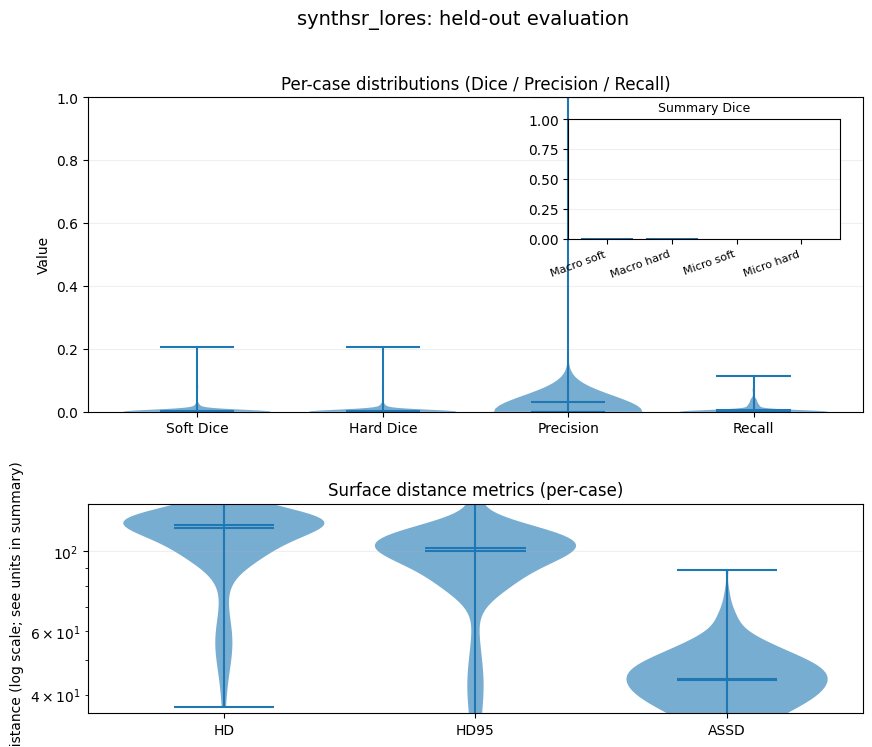

Composite figure: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_synthsr_lores_composite_20260330_164450.png
Merged CSV with manifest -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_synthsr_lores_metrics_with_manifest_20260330_164450.csv
Wrote summary CSV -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_synthsr_lores_summary_stats.csv
Datasets ready for plotting: ['synthsr_lores']
Rows: 198 | Saved per-case CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_synthsr_lores_metrics_20260330_164450.csv
Saved one-row summary CSV: /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/test_synthsr_lores_summary_stats.csv


In [8]:
# ===== Cell 3 (FINAL): RUN full evaluation on one dataset, compute summaries (no plots) =====
from pathlib import Path
import csv, json
import numpy as np
from typing import Dict, List, Any

# ---- small helpers (NaN-safe summaries) ----
def _dropna(a):
    a = np.asarray(a, float)
    return a[~np.isnan(a)]

def summarize_vector(x) -> Dict[str, float]:
    v = _dropna(np.array(x, float))
    if v.size == 0:
        return dict(n=0, mean=np.nan, median=np.nan, std=np.nan,
                    p25=np.nan, p75=np.nan, min=np.nan, max=np.nan, nan_count=len(x))
    return dict(
        n=int(v.size),
        mean=float(np.mean(v)),
        median=float(np.median(v)),
        std=float(np.std(v, ddof=1)) if v.size > 1 else 0.0,
        p25=float(np.percentile(v,25)),
        p75=float(np.percentile(v,75)),
        min=float(np.min(v)),
        max=float(np.max(v)),
        nan_count=int(len(x) - v.size),
    )

def summarize_dataset(rows: List[Dict[str, Any]]) -> Dict[str, Any]:
    soft = [r["soft_dice"] for r in rows]
    # detect the hard-dice column name we wrote in Cell 2
    hard_key = next((k for k in rows[0].keys() if k.startswith("hard_dice_at_")), "hard_dice_at_0.50")
    hard = [r[hard_key] for r in rows]
    prec = [r["precision"] for r in rows]
    rec  = [r["recall"]   for r in rows]
    hd   = [r["hd"]       for r in rows]
    hd95 = [r["hd95"]     for r in rows]
    assd = [r["assd"]     for r in rows]
    return {
        "soft": summarize_vector(soft),
        "hard": summarize_vector(hard),
        "prec": summarize_vector(prec),
        "rec":  summarize_vector(rec),
        "hd":   summarize_vector(hd),
        "hd95": summarize_vector(hd95),
        "assd": summarize_vector(assd),
    
    }

def write_summary_csv(summary_table: List[Dict[str, Any]], out_path: Path):
    if not summary_table:
        print("No summary to write."); return
    keys = sorted({k for row in summary_table for k in row.keys()})
    with open(out_path, "w", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=keys)
        wr.writeheader(); wr.writerows(summary_table)
    print("Wrote summary CSV ->", out_path)

# -------- RUN THIS BLOCK (edit paths/tag/prefix only) --------
RUN_DIR   = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813")
TEST_DIR  = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data/Upsampled_LowRes")
TRAIN_MOD = Path("/home/rbielski/stroke_cleaned/stroke_segmentation_v1.2/stroke_seg_v1.2_train.py")
T1_DIR    = TEST_DIR / "t1"
MSK_DIR   = TEST_DIR / "masks"
MANIFEST  = Path("/home/rbielski/ARC/ds004884/derivatives/aggregates/t1w_with_masks/mni_1mm_ants_fixed/_standardized/_combined_manifests_2bins_normal/combined_hires_lores_manifest.csv")

DATASET_TAG = "synthsr_lores"         # <<< change per dataset (e.g., "lores", "thickslice")
SAVE_PREFIX = "test_synthsr_lores"     # <<< change per dataset

# 1) Run the full evaluation over ALL images (model inference + metrics + CSV/JSON/PNG)
rows, summary, paths = run_eval_and_viz(
    RUN_DIR=RUN_DIR, TEST_DIR=TEST_DIR, TRAIN_MOD_PATH=TRAIN_MOD,
    T1_DIR=T1_DIR, MSK_DIR=MSK_DIR, MANIFEST_CSV=MANIFEST,
    TH=0.50, save_prefix=SAVE_PREFIX, dataset_tag=DATASET_TAG
)

# 2) Build the 'datasets' dict Cell 4 expects (from in-memory rows)
datasets: Dict[str, Dict[str, Any]] = {
    DATASET_TAG: {
        "rows": rows,                         # per-case metrics (list of dicts)
        "summary": summarize_dataset(rows),   # mean/median/std/etc per metric
        "source_paths": [paths["per_case_csv"]]
    }
}

# 3) Also write a tiny one-row summary CSV for this dataset (next to the per-case CSV)
summary_table = []
flat = {"dataset_tag": DATASET_TAG}
for metric, stats in datasets[DATASET_TAG]["summary"].items():
    for k, v in stats.items():
        flat[f"{metric}_{k}"] = v
summary_table.append(flat)
out_summary = Path(paths["per_case_csv"]).with_name(f"{SAVE_PREFIX}_summary_stats.csv")
write_summary_csv(summary_table, out_summary)

print("Datasets ready for plotting:", list(datasets.keys()))
print(f"Rows: {len(datasets[DATASET_TAG]['rows'])} | Saved per-case CSV: {paths['per_case_csv']}")
print(f"Saved one-row summary CSV: {out_summary}")


In [9]:
# === Pretty grouped violins (final tweaks) ===
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path
from typing import Dict, Any, List

PALETTE       = ["#4C78A8"]      # add more colors if plotting multiple datasets
POINT_ALPHA   = 0.55
POINT_SIZE    = 10
VIOLIN_ALPHA  = 0.18             # extra transparent so dots show clearly
EDGE_ALPHA    = 0.35
ROBUST_PERC   = (5, 95)
JITTER_WIDTH  = 0.08
SEED          = 7
_rng = np.random.default_rng(SEED)

def _dropna(a): 
    a = np.asarray(a, float); 
    return a[~np.isnan(a)]

def _robust_limits_linear(arr, p=(5,95), min_span=1e-6):
    arr = _dropna(arr)
    if arr.size == 0: return (0.0, 1.0)
    lo, hi = np.percentile(arr, p[0]), np.percentile(arr, p[1])
    if hi - lo < min_span: hi = lo + min_span
    return float(lo), float(hi)

def _beeswarm_x(center: float, n: int, spread: float) -> np.ndarray:
    if n == 0: return np.array([])
    return center + _rng.normal(0.0, spread, size=n)

def _get_val(row: Dict[str, Any], key: str):
    if key == "soft": return row.get("soft", row.get("soft_dice"))
    if key == "hard":
        for k in row.keys():
            if k.startswith("hard_dice"): return row[k]
        return row.get("hard")
    if key == "prec": return row.get("prec", row.get("precision"))
    if key == "rec":  return row.get("rec",  row.get("recall"))
    return row.get(key)  # hd, hd95, assd

def pretty_violins_from_datasets(
    datasets: Dict[str, Dict[str, Any]],
    title: str = "Higher Resolution Images Test Set",
    legend_label: str = "Individual Image Segmentation",
    distance_units: str = "mm",
    save_path = None,
    show_legend = False
):
    if not datasets:
        print("No datasets to plot."); 
        return None
    

    tags = sorted(datasets.keys())

    def metric_arrays(std_key: str) -> List[np.ndarray]:
        return [ _dropna([_get_val(r, std_key) for r in datasets[tag]["rows"]]) for tag in tags ]

    # arrays
    soft, hard, prec, rec  = (metric_arrays(k) for k in ["soft","hard","prec","rec"])
    hd, hd95, assd         = (metric_arrays(k) for k in ["hd","hd95","assd"])

    plt.style.use("default")
    fig = plt.figure(figsize=(12, 8))
    gs  = GridSpec(2, 1, height_ratios=[3, 2], hspace=0.40)
    ax_top = fig.add_subplot(gs[0])
    ax_bot = fig.add_subplot(gs[1])

    def draw_grouped(ax, data_seq: List[List[np.ndarray]], base_labels: List[str],
                    ylabel=None, panel_title=None, is_distance=False):
        groups = len(data_seq)
        nd     = len(tags)
        base_x = np.arange(1, groups+1, dtype=float)
        width, step = 0.9, 0.9/(nd+1)

        # remove any leftover legend from previous runs
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        all_vals = []
        for di, tag in enumerate(tags):
            color  = PALETTE[di % len(PALETTE)]
            offset = (di - (nd-1)/2) * step
            for gi in range(groups):
                vals = data_seq[gi][di]
                all_vals.append(vals)
                pos = base_x[gi] + offset
                parts = ax.violinplot([vals if vals.size else np.array([np.nan])],
                                    positions=[pos], widths=step*0.95,
                                    showmeans=True, showmedians=True)
                for b in parts.get('bodies', []):
                    b.set_facecolor(color)
                    b.set_edgecolor((0,0,0,EDGE_ALPHA))
                    b.set_alpha(VIOLIN_ALPHA)
                if 'cmeans' in parts:
                    parts['cmeans'].set_linewidth(1.6); parts['cmeans'].set_color((0,0,0,0.85))
                if 'cmedians' in parts:
                    parts['cmedians'].set_linewidth(1.6); parts['cmedians'].set_color((0,0,0,0.85))
                if vals.size:
                    xs = _beeswarm_x(pos, len(vals), JITTER_WIDTH)
                    ax.scatter(xs, vals, s=POINT_SIZE, alpha=POINT_ALPHA, color=color, edgecolor='none')

        ax.set_xticks(base_x)
        ax.set_xticklabels(base_labels)
        if ylabel: ax.set_ylabel(ylabel)
        if panel_title: ax.set_title(panel_title, pad=18)
        flat = np.concatenate([v for v in all_vals if v.size]) if any(v.size for v in all_vals) else np.array([])
        if flat.size:
            lo, hi = _robust_limits_linear(flat, p=ROBUST_PERC)
            if not is_distance:
                lo = max(0.0, lo); hi = min(1.0, max(0.9, hi))
            ax.set_ylim(lo, hi)
        ax.grid(True, axis='y', alpha=0.25)

        # only add legend if requested
        if show_legend:
            ax.plot([], [], marker='o', ls='', color=PALETTE[0], label=legend_label)
            ax.legend(loc="upper left", bbox_to_anchor=(1.23, 1.03), frameon=False)


    # Top (Dice/PR)
    draw_grouped(
        ax_top,
        data_seq=[soft, hard, prec, rec],
        base_labels=["Soft Dice", "Hard Dice", "Precision", "Recall"],
        ylabel="Value",
        panel_title="Per-case distributions (Dice / Precision / Recall)",
        is_distance=False
    )

    # Bottom (Distances) — linear + units
    draw_grouped(
        ax_bot,
        data_seq=[hd, hd95, assd],
        base_labels=["HD", "HD95", "ASSD"],
        ylabel=f"Distance ({distance_units})",
        panel_title="Surface distance metrics (per-case)",
        is_distance=True
    )

    # Figure title (exact text you asked for)
    fig.suptitle(title, y=0.99, fontsize=16)
    plt.tight_layout()

    # Save
    if save_path is None:
        any_row = next(iter(datasets[tags[0]]["rows"]), None)
        default_dir = Path(any_row["img_path"]).parent if any_row and any_row.get("img_path") else Path(".")
        save_path = default_dir / "pretty_violins_linear_final.png"
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    print("Saved figure ->", save_path)

    plt.show()
    return fig


Saved figure -> /home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/lores_pretty_violins.png


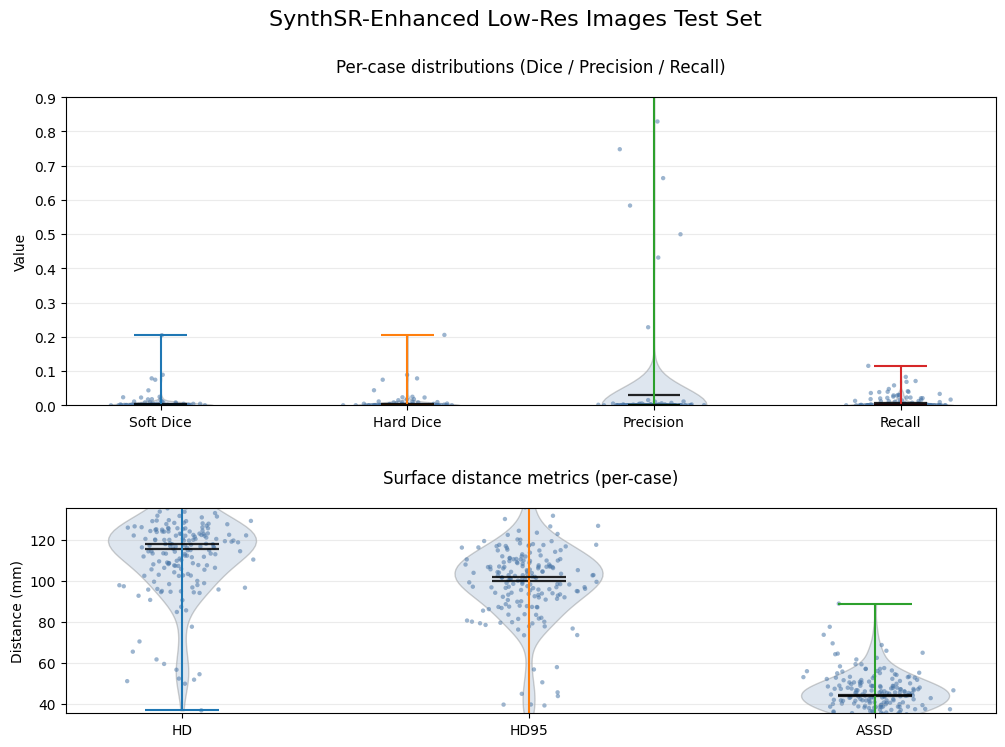

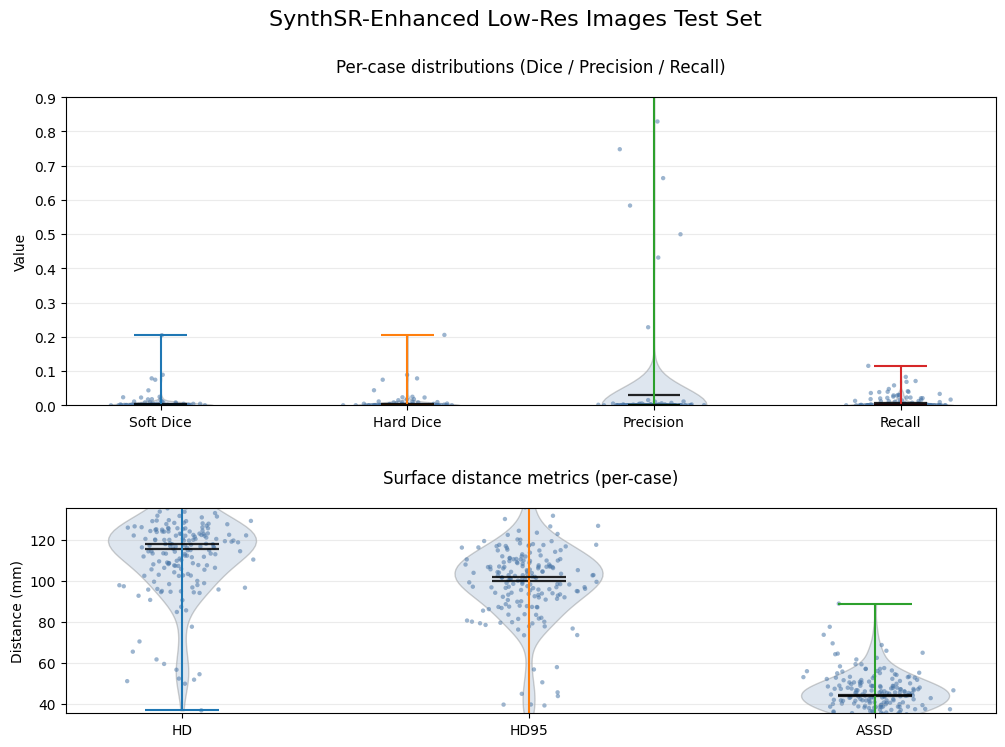

In [10]:
# Cell 4: call the plotter for the lores run
from pathlib import Path

pretty_violins_from_datasets(
    datasets,                              # this was built in your new Cell 3
    title="SynthSR-Enhanced Low-Res Images Test Set",
    distance_units="mm",
    show_legend=False,
    save_path=Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/runs/20251110_101813/test_eval/lores_pretty_violins.png")
)
